[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/probability_statistics/06_expectation_variance_and_moments/first_principles.ipynb)

# Module 06 — Expectation, Variance and Moments

### 0. Setup

The shared preamble. Every random number in this notebook comes from the single generator `rng`, so every printed figure below reproduces exactly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

Seeding is centralised: `rng` is the only randomness source used anywhere below.

## 1. Why This Module Exists

A distribution carries infinitely much information. Decisions do not: a controller needs a setpoint, a trader needs an expected return, an optimizer needs a gradient. **Moments** are the finite summaries that compress a law into numbers, and expectation is the first and most consequential of them:

$$
E[X] = \int_{\Omega} X(\omega)\,dP(\omega) = \int_{\mathbb{R}} x\,dF_X(x).
$$

Read the middle expression literally — expectation is an *integral of a function against a measure*. Everything that follows is a property of integrals. Linearity is the deepest of these, and it is unconditional: for any integrable $X$ and $Y$, however wildly dependent,

$$
E[aX + bY] = a\,E[X] + b\,E[Y].
$$

No independence, no identical distribution, no continuity. This is the single most useful fact in applied probability, because it lets us decompose complicated random quantities into simple pieces and average each piece separately, ignoring the dependence entirely.

Three questions organise the module. *What can one number tell us?* — expectation, and the inequalities (Markov, Chebyshev, Chernoff) that convert a moment into a probability statement. *What can a whole sequence of numbers tell us?* — moments, cumulants, and the generating functions that package them, together with the sharp limits on how much a moment sequence can ever determine. *What happens when we condition?* — the tower property and the law of total variance, which split uncertainty into the part a measurement can remove and the part it cannot.

### 1.1 What Higher Moments Buy, and What They Cost

The mean locates a distribution; the variance measures its spread; the third and fourth standardized moments describe asymmetry and tail weight. Each order added is a sharper description — but each also demands more integrability, and heavy-tailed laws refuse to pay.

- **First moment**: needs $E\lvert X \rvert \lt \infty$. Cauchy fails; sample averages of Cauchy data never converge.
- **Second moment**: needed for variance, least-squares, the CLT. Student's $t_2$ fails.
- **All moments plus an MGF near 0**: needed for Chernoff bounds and for moments to determine the law. Lognormal fails on both counts.

Two structural conveniences justify the effort. **LOTUS** (the Law of the Unconscious Statistician) computes $E[g(X)]$ from the law of $X$ alone, with no need to derive the law of $g(X)$. And **generating functions** — $M_X(t) = E[e^{tX}]$, $K_X = \ln M_X$, $\varphi_X(t) = E[e^{itX}]$ — convert convolution into multiplication and moment extraction into differentiation, turning distributional questions into calculus.

Finally, conditioning gives moments a dynamic character. The tower property and the law of total variance split uncertainty into an irreducible part and a learnable part, which is exactly the aleatoric/epistemic distinction that modern predictive systems are asked to report.

## 2. Intuition

Two pictures carry almost everything.

**Expectation is a balance point.** Put mass $p_k$ at position $x_k$ on a weightless rod. The rod balances at $\mu = \sum_k x_k p_k$, because balancing means the signed moments cancel, $\sum_k (x_k - \mu)p_k = 0$ — which is exactly the definition of the mean rearranged. The variance is then the *moment of inertia* about that balance point, $\sigma^2 = \sum_k (x_k-\mu)^2 p_k$: mass far from the centre costs quadratically, which is why a single outlier moves a variance far more than it moves a mean.

Because balancing is a statement about a *sum of masses*, sliding all the mass of two rods together balances at the sum of the two balance points no matter how the masses were paired up. That is linearity, and it is why dependence is invisible to expectation.

**Nonlinearity bends the balance point.** If we transform each position by $g$ before balancing, the new balance point is $E[g(X)]$, not $g(\mu)$. For convex $g$ the graph lies above every one of its tangent lines, so averaging the *heights* $g(x_k)$ overshoots the height $g(\mu)$ above the average *position*. The overshoot is Jensen's gap; it is systematic, one-signed, and it does not shrink with more data — it is a bias, not noise.

The figure below draws both pictures on the same three-point law.

**Figure 1 — the balance point and Jensen's gap.** Left: a three-point law with its mean marked as a fulcrum and $\mu \pm \sigma$ as the inertia scale. Right: the same law pushed through the convex $g(x) = e^{x}$; the chord polygon of the mass points lies above the curve, and the vertical gap at $x = \mu$ is $E[g(X)] - g(E[X])$.

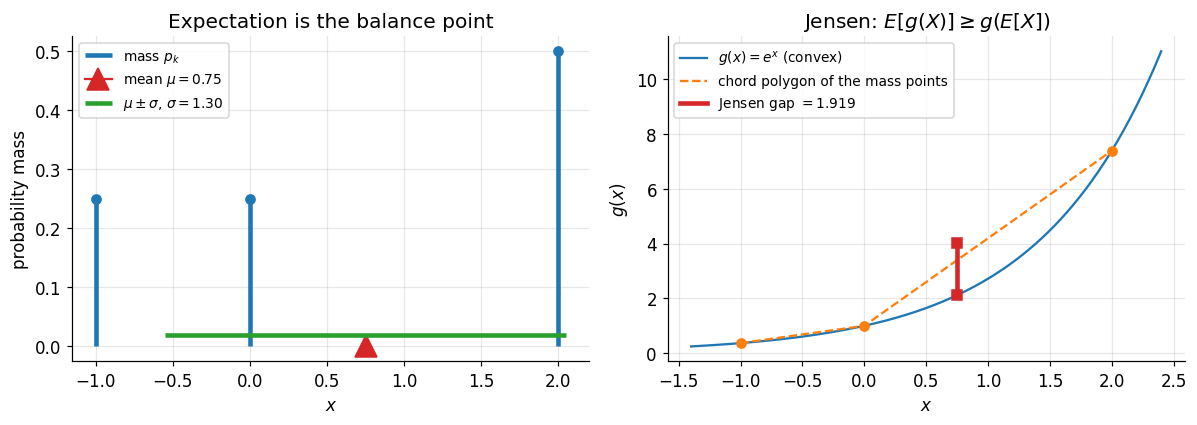

mu = 0.7500   sigma^2 = 1.6875
E[g(X)] = 4.036498   g(E[X]) = 2.117000   gap = 1.919498


In [2]:
xs = np.array([-1.0, 0.0, 2.0])
ps = np.array([0.25, 0.25, 0.50])
mu = float(xs @ ps)
var = float(ps @ (xs - mu) ** 2)
sd = np.sqrt(var)

Eg = float(ps @ np.exp(xs))
g_mu = float(np.exp(mu))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.0, 4.0))

ax1.vlines(xs, 0, ps, color="C0", linewidth=3, label="mass $p_k$")
ax1.plot(xs, ps, "o", color="C0")
ax1.plot([mu], [0], marker="^", markersize=14, color="C3", label=fr"mean $\mu={mu:.2f}$")
ax1.hlines(0.02, mu - sd, mu + sd, color="C2", linewidth=3, label=fr"$\mu\pm\sigma$, $\sigma={sd:.2f}$")
ax1.set_xlabel("$x$")
ax1.set_ylabel("probability mass")
ax1.set_title("Expectation is the balance point")
ax1.legend(loc="upper left", fontsize=9)

grid = np.linspace(-1.4, 2.4, 300)
ax2.plot(grid, np.exp(grid), color="C0", label="$g(x)=e^x$ (convex)")
ax2.plot(xs, np.exp(xs), "o", color="C1")
ax2.plot(xs, np.exp(xs), "--", color="C1", label="chord polygon of the mass points")
ax2.plot([mu, mu], [g_mu, Eg], color="C3", linewidth=3,
         label=fr"Jensen gap $={Eg - g_mu:.3f}$")
ax2.plot([mu], [g_mu], "s", color="C3")
ax2.plot([mu], [Eg], "s", color="C3")
ax2.set_xlabel("$x$")
ax2.set_ylabel("$g(x)$")
ax2.set_title("Jensen: $E[g(X)] \\geq g(E[X])$")
ax2.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

print(f"mu = {mu:.4f}   sigma^2 = {var:.4f}")
print(f"E[g(X)] = {Eg:.6f}   g(E[X]) = {g_mu:.6f}   gap = {Eg - g_mu:.6f}")

The fulcrum sits at $\mu = 0.75$ even though no mass sits there, and the inertia bar $\mu \pm \sigma$ is wide because a quarter of the mass sits at distance $1.75$. On the right the three transformed points lie on the curve, but their average — the height of the dashed polygon above $x = \mu$ — sits $1.92$ above the curve. That gap is not an artefact of the sample: it is a property of the law, and it is the reason $E[g(X)]$ must be computed under the distribution rather than by plugging the mean into $g$.

## 3. Definitions

**Definition 3.1 (Expectation).** For $X \ge 0$, $E[X] = \int_\Omega X\,dP \in [0,\infty]$ is defined as the supremum of integrals of simple functions below $X$. For general $X$, write $X = X^{+} - X^{-}$; if $E\left[\lvert X \rvert\right] = E[X^+] + E[X^-] \lt \infty$ then $X$ is *integrable* and $E[X] = E[X^+] - E[X^-]$. Concretely,

$$
E[X] = \sum_{k}x_k\,p_X(x_k) \quad \text{(discrete)}, \qquad E[X] = \int_{-\infty}^{\infty}x f_X(x)\,dx \quad \text{(continuous)}.
$$

**Definition 3.2 (Variance, Covariance, Correlation).** For square-integrable $X, Y$:

$$
\mathrm{Var}(X) = E\left[(X-\mu_X)^2\right] = E[X^2] - \mu_X^2, \qquad \mathrm{Cov}(X,Y) = E\left[(X-\mu_X)(Y-\mu_Y)\right] = E[XY] - \mu_X\mu_Y,
$$

and, **provided $\mathrm{Var}(X) \gt 0$ and $\mathrm{Var}(Y) \gt 0$**,

$$
\rho(X,Y) = \frac{\mathrm{Cov}(X,Y)}{\sqrt{\mathrm{Var}(X)\mathrm{Var}(Y)}}.
$$

If either variance is zero the ratio is $0/0$ and $\rho$ is simply undefined — a degenerate variable has no direction to correlate with. The bound $\lvert \rho \rvert \le 1$ is not part of the definition; it is Cauchy-Schwarz (Theorem 4.5, item 5), and equality holds if and only if $Y = a + bX$ almost surely for some $b \ne 0$, with $\rho = \operatorname{sign}(b)$.

**Definition 3.3 (Moments, Central Moments, Standardized Moments).** The $n$-th raw moment is $m_n = E[X^n]$, the $n$-th central moment is $\mu_n = E\left[(X-\mu)^n\right]$, and the standardized ones are

$$
\text{skewness } \gamma_1 = \frac{\mu_3}{\sigma^3}, \qquad \text{kurtosis } \beta_2 = \frac{\mu_4}{\sigma^4}, \qquad \text{excess kurtosis } = \beta_2 - 3.
$$

Each requires the corresponding integrability: $m_n$ exists only when $E\lvert X \rvert^{n} \lt \infty$. The subtraction of 3 uses the Gaussian as the reference: $\beta_2 = 3$ for every normal law.

**Definition 3.4 (Generating Functions).**

$$
M_X(t) = E\left[e^{tX}\right], \qquad K_X(t) = \ln M_X(t), \qquad \varphi_X(t) = E\left[e^{itX}\right].
$$

$\varphi_X$ exists for every random variable and every real $t$, since $\left\lvert e^{itX} \right\rvert = 1$; $M_X$ may be infinite off $t = 0$, and $K_X$ is defined only where $M_X$ is finite and positive.

**Definition 3.5 (Conditional Expectation).** Let $E\lvert X \rvert \lt \infty$. Then $E[X \mid Y]$ is the almost surely unique $\sigma(Y)$-measurable, integrable random variable $g(Y)$ satisfying

$$
E\left[g(Y)\mathbf{1}_A\right] = E\left[X\mathbf{1}_A\right] \quad \text{for every } A \in \sigma(Y).
$$

*Existence* is not automatic from this characterisation: it follows from the Radon-Nikodym theorem applied to the finite signed measure $\nu(A) = E[X\mathbf{1}_A]$ on $\sigma(Y)$, which is absolutely continuous with respect to $P$ restricted to $\sigma(Y)$ (Billingsley, *Probability and Measure*, 3rd ed., §34, Thm 34.1); integrability $E\lvert X\rvert \lt \infty$ is exactly what makes $\nu$ finite. When $X \in L^2$ there is a second, more elementary route: $E[X \mid Y]$ is the orthogonal projection of $X$ onto the closed subspace $L^2(\sigma(Y))$, whose existence is the Hilbert-space projection theorem — the construction carried out in Problem L3.1 of [`exercises.ipynb`](exercises.ipynb).

Geometrically, that projection picture is why $E[X \mid Y]$ is the minimizer of mean squared prediction error (Theorem 4.6, item 4).

## 4. Main Results

Every hypothesis below is stated inline, and each is followed by one sentence saying why it cannot be dropped.

**Theorem 4.1 (Linearity, Monotonicity, and the Tail Formula).** Let $X, Y$ be integrable on a common probability space and $a, b \in \mathbb{R}$. Then

1. $E[aX + bY] = aE[X] + bE[Y]$;
2. $X \le Y$ almost surely implies $E[X] \le E[Y]$, and $\left\lvert E[X] \right\rvert \le E\left[\lvert X \rvert\right]$;
3. if in addition $X \ge 0$, then $E[X] = \int_0^{\infty}P(X \gt t)\,dt$, and for integer-valued $X \ge 0$, $E[X] = \sum_{n \ge 0}P(X \gt n)$.

*Hypotheses.* Integrability is needed so that $E[X^+]-E[X^-]$ is not $\infty-\infty$ — for two Cauchy variables $E[X+Y]$ and $E[X]+E[Y]$ are both meaningless. "On a common space" is needed because $X+Y$ must be a random variable at all, which requires a joint law. Non-negativity in item 3 is needed because the layer-cake identity $X = \int_0^\infty \mathbf{1}\{X \gt t\}\,dt$ is false for $X \lt 0$. Note that *independence appears nowhere*.

$$
\boxed{E\left[\sum_{i=1}^{n} X_i\right] = \sum_{i=1}^{n} E[X_i] \quad \text{for all integrable } X_i, \text{ dependent or not}}
$$

**Interpretation.** The mean of a sum never needs the joint law — only the $n$ marginals. The consequence is a proof technique: write a complicated count as a sum of indicators, each of whose means is a one-line probability, and read off the answer without ever computing the distribution of the count (Example 6.1).

**Theorem 4.2 (LOTUS / change of variables).** Let $X$ be a random variable and $g:\mathbb{R}\to\mathbb{R}$ Borel measurable with $E\left\lvert g(X) \right\rvert \lt \infty$. Then

$$
E\left[g(X)\right] = \int_{\mathbb{R}} g\,dP_X = \sum_k g(x_k)p_X(x_k) \quad \text{(discrete)}, \qquad E\left[g(X)\right] = \int_{\mathbb{R}}g(x)f_X(x)\,dx \quad \text{(density case)},
$$

with no need to compute the distribution of $g(X)$.

*Hypotheses.* Measurability of $g$ is needed for $g(X)$ to be a random variable; $E\lvert g(X)\rvert \lt \infty$ is needed for both sides to be finite numbers rather than a divergent rearrangement; the density form needs $X$ to actually have a density $f_X$ with respect to Lebesgue measure.

**Theorem 4.3 (Algebra of Variance).** For square-integrable variables: $\mathrm{Var}(aX+b) = a^2\mathrm{Var}(X)$; $\mathrm{Cov}$ is symmetric and bilinear; and with $\Sigma_{ij} = \mathrm{Cov}(X_i,X_j)$,

$$
\mathrm{Var}\left(\sum_{i=1}^{n}X_i\right) = \sum_{i=1}^{n}\mathrm{Var}(X_i) + 2\sum_{i \lt j}\mathrm{Cov}(X_i, X_j) = \mathbf{1}^{\top}\Sigma\,\mathbf{1}, \qquad \mathrm{Var}\left(w^{\top}X\right) = w^{\top}\Sigma w .
$$

If the $X_i$ are pairwise **uncorrelated** the cross terms vanish and variance is additive.

*Hypotheses.* Square-integrability is needed for $\Sigma$ to exist at all ($t_2$ data has no covariance matrix). Only *uncorrelatedness* — not independence — is needed for additivity; independence is strictly stronger, and the converse fails ($X\sim\mathcal N(0,1)$, $Y=X^2$ are uncorrelated and functionally dependent).

**Theorem 4.4 (Generating-Function Toolkit).** Suppose $M_X(t) \lt \infty$ for all $t$ in an open interval containing $0$. Then

1. $M_X$ is infinitely differentiable there and $E[X^n] = M_X^{(n)}(0)$ for every $n$;
2. $M_X$ determines $F_X$ uniquely;
3. if $X \perp\!\!\!\perp Y$ and both MGFs are finite near 0, then $M_{X+Y} = M_XM_Y$ and $K_{X+Y} = K_X + K_Y$;
4. the cumulants $\kappa_n = K_X^{(n)}(0)$ satisfy $\kappa_1 = \mu$, $\kappa_2 = \sigma^2$, $\kappa_3 = \mu_3$, $\kappa_4 = \mu_4 - 3\sigma^4$, and are additive over independent summands.

*Hypotheses.* Finiteness on an *open interval around* 0 is the whole content: it is what licenses differentiating under the integral sign in item 1 and the analytic-continuation argument behind item 2. Finiteness only at $t=0$ is vacuous ($M_X(0)=1$ always). Independence in item 3 is what turns $E[e^{tX}e^{tY}]$ into a product. Without any MGF, items 2 and 3 survive verbatim with $\varphi_X$ in place of $M_X$ (Lévy's inversion and continuity theorems), which is why characteristic functions are the safe default.

**Theorem 4.5 (Inequalities).**

1. **Markov**: if $X \ge 0$ and $a \gt 0$ then $P(X \ge a) \le E[X]/a$;
2. **Chebyshev**: if $\sigma^2 = \mathrm{Var}(X) \lt \infty$ and $k \gt 0$ then $P\left(\lvert X - \mu \rvert \ge k\sigma\right) \le 1/k^2$;
3. **Chernoff**: if $M_X(t) \lt \infty$ for some $t \gt 0$ then $P(X \ge a) \le \inf_{t \gt 0} e^{-ta}M_X(t)$;
4. **Jensen**: if $g$ is convex on an interval containing the support of $X$ and $E\lvert X\rvert \lt \infty$, $E\lvert g(X)\rvert \lt \infty$, then $E\left[g(X)\right] \ge g\left(E[X]\right)$, with equality iff $g$ is affine on the support of $X$;
5. **Cauchy-Schwarz**: if $E[X^2], E[Y^2] \lt \infty$ then $\left\lvert E[XY] \right\rvert \le \sqrt{E[X^2]E[Y^2]}$, with equality iff $X$ and $Y$ are almost surely proportional.

*Hypotheses.* Markov needs $X \ge 0$ — otherwise negative mass can hide a large tail while keeping $E[X]$ small. Chebyshev needs a *finite* second moment, and is vacuous without one, which is exactly what happens for Cauchy data (Section 7.4). Chernoff needs the MGF to be finite somewhere to the right of 0; a Pareto or Lognormal variable has $M_X(t)=\infty$ for every $t \gt 0$ and admits no exponential tail bound. Jensen needs convexity on a set containing the support, not merely at the mean.

**Theorem 4.6 (Tower Property, Total Variance, and Optimal Prediction).** Let $E\lvert X\rvert \lt \infty$ (and $E[X^2] \lt \infty$ for items 3 and 4). Then

1. **Tower / Adam's law**: $E\left[E[X \mid Y]\right] = E[X]$;
2. **Taking out what is known**: $E\left[h(Y)X \mid Y\right] = h(Y)E[X \mid Y]$ whenever $h(Y)X$ is integrable;
3. **Law of total variance / Eve's law**:

$$
\mathrm{Var}(X) = E\left[\mathrm{Var}(X \mid Y)\right] + \mathrm{Var}\left(E[X \mid Y]\right);
$$

4. **Optimal predictor**: $\min_{g \text{ measurable}} E\left[(X - g(Y))^2\right]$ is attained at $g^{\star}(Y) = E[X \mid Y]$, with minimum value $E\left[\mathrm{Var}(X \mid Y)\right]$.

*Hypotheses.* $E\lvert X\rvert \lt \infty$ is what makes $E[X\mid Y]$ exist (Definition 3.5). $E[X^2] \lt \infty$ is needed in items 3 and 4 because both are statements about squared distances in $L^2$; with an infinite second moment the decomposition reads $\infty = \infty + \infty$. The integrability side condition in item 2 is needed because $h(Y)X$ can fail to be integrable even when $X$ is.

$$
\boxed{\mathrm{Var}(X) = \underbrace{E\left[\mathrm{Var}(X \mid Y)\right]}_{\text{unexplained by } Y} + \underbrace{\mathrm{Var}\left(E[X \mid Y]\right)}_{\text{explained by } Y}}
$$

**Interpretation.** Conditioning splits total uncertainty into a part that observing $Y$ removes and a part it never will. The consequence is a hard ceiling on prediction: no function of $Y$, however expressive, can push mean squared error below $E[\mathrm{Var}(X\mid Y)]$, so a model that has reached that floor is not underfitting — it has run out of information, and only a different measurement can help.

**Corollary 4.7 (Bias-variance decomposition).** For an estimator $\hat\theta$ of a fixed $\theta$ with $E[\hat\theta^{\,2}] \lt \infty$,

$$
\mathrm{MSE}(\hat\theta) = E\left[(\hat{\theta}-\theta)^2\right] = \left(E[\hat\theta] - \theta\right)^2 + \mathrm{Var}(\hat\theta) .
$$

*Hypothesis.* A finite second moment is needed for both terms to be finite; $\theta$ must be non-random, otherwise the cross term does not vanish.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1)

**Linearity.** For simple functions $X = \sum_i a_i\mathbf{1}_{A_i}$ and $Y = \sum_j b_j\mathbf{1}_{B_j}$ with $\{A_i\}$ and $\{B_j\}$ each a finite partition of $\Omega$, refine to the common partition $\{A_i \cap B_j\}$:

$$
E[X+Y] = \sum_{i,j}(a_i + b_j)P(A_i \cap B_j) = \sum_{i,j}a_iP(A_i \cap B_j) + \sum_{i,j}b_jP(A_i \cap B_j) = E[X] + E[Y],
$$

where the last step summed out $j$ then $i$ using finite additivity — **no product rule $P(A \cap B) = P(A)P(B)$ was ever used**, which is exactly why independence is irrelevant. For general non-negative $X, Y$ choose simple $X_n \uparrow X$, $Y_n \uparrow Y$ (for instance $X_n = 2^{-n}\lfloor 2^nX\rfloor \wedge n$); then $X_n + Y_n \uparrow X+Y$ and the monotone convergence theorem passes the identity to the limit. For signed integrable $X$, split $X = X^+-X^-$ and use the non-negative case on the four pieces; $aX$ is handled by the same three steps with $a \ge 0$, and $a \lt 0$ by swapping $X^+$ and $X^-$. $\blacksquare$

**Monotonicity.** If $X \le Y$ a.s. then $Y - X \ge 0$, so $E[Y-X] \ge 0$ by Definition 3.1, and linearity gives $E[Y] \ge E[X]$. Applying this to $-\lvert X\rvert \le X \le \lvert X\rvert$ gives $\lvert E[X]\rvert \le E\lvert X\rvert$. $\blacksquare$

**Tail formula.** Write $X = \int_0^{\infty}\mathbf{1}\{X \gt t\}\,dt$ pointwise (the integrand is 1 for $t \lt X$ and 0 after), then exchange the order of integration by Tonelli's theorem, which applies because the integrand is non-negative and jointly measurable:

$$
E[X] = E\left[\int_0^{\infty}\mathbf{1}\{X \gt t\}dt\right] = \int_0^{\infty}E\left[\mathbf{1}\{X \gt t\}\right]dt = \int_0^{\infty}P(X \gt t)\,dt.
$$

For integer-valued $X \ge 0$ the function $t \mapsto P(X \gt t)$ is constant on each $[n, n+1)$, so the integral collapses to $\sum_{n\ge0}P(X \gt n)$. $\blacksquare$

**Two payoffs.** For $X \sim \text{Exponential}(\lambda)$ the tail formula gives $E[X] = \int_0^\infty e^{-\lambda t}dt = 1/\lambda$ with no integration by parts, and for $X\sim\text{Geometric}(p)$ on $\{0,1,2,\dots\}$ it gives $\sum_{n\ge0}(1-p)^{n+1} = (1-p)/p$ instantly. For linearity, drawing $n$ of $N$ items containing $K$ successes *without replacement* makes the draws dependent, yet each has marginal success probability $K/N$, so $E[X] = nK/N$ — identical to the Binomial mean even though the variances differ.

### Proof 5.2 (of Theorem 4.2)

**Discrete case.** Let $Y = g(X)$ with values $\{y_j\}$. By Definition 3.1 and by partitioning the preimages,

$$
E[Y] = \sum_j y_j P(Y = y_j) = \sum_j y_j\!\!\sum_{x : g(x) = y_j}\!\! p_X(x) = \sum_j \sum_{x : g(x)=y_j} g(x)p_X(x) = \sum_x g(x)p_X(x),
$$

since the preimage sets $\{x : g(x) = y_j\}$ partition the support of $X$ and $g(x) = y_j$ on the $j$-th block. Absolute convergence, guaranteed by $E\lvert g(X)\rvert \lt \infty$, justifies the rearrangement. $\blacksquare$

**General case, by the standard machine.** Let $P_X = P \circ X^{-1}$ be the pushforward law on $\mathbb{R}$. The claim is $\int_\Omega g(X)\,dP = \int_{\mathbb{R}} g\,dP_X$, proved in four steps of increasing generality.

1. *Indicators.* For $g = \mathbf{1}_B$ with $B$ Borel, $g(X) = \mathbf{1}\{X \in B\}$, so $\int_\Omega g(X)dP = P(X \in B) = P_X(B) = \int_{\mathbb{R}}\mathbf{1}_B\,dP_X$. This is the definition of the pushforward and nothing more.
2. *Simple functions.* For $g = \sum_{k=1}^{m} c_k\mathbf{1}_{B_k}$ apply step 1 to each term and use linearity of both integrals (Proof 5.1).
3. *Non-negative $g$.* Choose simple $g_n \uparrow g$ pointwise, e.g. $g_n = 2^{-n}\lfloor 2^n g\rfloor \wedge n$. Then $g_n(X) \uparrow g(X)$ pointwise on $\Omega$, and monotone convergence applied on both sides gives $\int_\Omega g(X)dP = \lim_n \int_\Omega g_n(X)dP = \lim_n\int_{\mathbb{R}}g_n dP_X = \int_{\mathbb{R}}g\,dP_X$.
4. *General $g$.* Split $g = g^+-g^-$; step 3 applies to each, and $E\lvert g(X)\rvert \lt \infty$ makes both finite, so the difference is well defined.

Specialising the resulting identity $\int_{\mathbb{R}}g\,dP_X$ to a discrete $P_X$ recovers the sum, and to $dP_X = f_X\,dx$ recovers $\int g f_X\,dx$. $\blacksquare$

### Proof 5.3 (of Theorem 4.3, and of Theorem 4.5 item 5)

**Variance algebra.** Bilinearity of $\mathrm{Cov}$ is linearity of expectation applied twice to $E[(X-\mu_X)(Y-\mu_Y)]$; symmetry is commutativity of multiplication. Then, with $S = \sum_i X_i$ and $\bar\mu = \sum_i \mu_i$,

$$
\mathrm{Var}(S) = E\left[\left(\sum_i (X_i-\mu_i)\right)^{2}\right] = \sum_{i,j} E\left[(X_i-\mu_i)(X_j-\mu_j)\right] = \sum_{i,j}\Sigma_{ij} = \mathbf{1}^\top\Sigma\mathbf{1},
$$

where expanding the square and exchanging the finite sum with $E$ is again Proof 5.1. Splitting the double sum into $i = j$ and $i \ne j$ gives the stated form, and $\mathrm{Var}(aX+b) = E[a^2(X-\mu)^2] = a^2\mathrm{Var}(X)$. $\blacksquare$

**Cauchy-Schwarz with its equality case.** For $E[Y^2] \gt 0$ and any $t \in \mathbb{R}$,

$$
0 \le E\left[(X - tY)^2\right] = E[X^2] - 2t\,E[XY] + t^2E[Y^2] =: q(t).
$$

$q$ is a non-negative quadratic in $t$, so its discriminant is non-positive: $4E[XY]^2 - 4E[X^2]E[Y^2] \le 0$, which is the inequality. Equality forces the discriminant to vanish, so $q$ has a double root $t^\star = E[XY]/E[Y^2]$ with $E[(X-t^\star Y)^2] = 0$, i.e. $X = t^\star Y$ almost surely. If $E[Y^2]=0$ then $Y = 0$ a.s. and both sides are 0. $\blacksquare$

**Consequence for correlation.** Apply this to the centred variables $X-\mu_X$ and $Y-\mu_Y$: $\lvert\mathrm{Cov}(X,Y)\rvert \le \sigma_X\sigma_Y$, i.e. $\lvert\rho\rvert\le1$, with equality iff $X-\mu_X = t^\star(Y-\mu_Y)$ almost surely — an exact affine relation. This is the sentence that makes $\rho$ interpretable: $\rho^2$ is the fraction of the variance of $X$ recovered by the best affine function of $Y$.

### Proof 5.4 (of Theorem 4.5, items 1-3)

**Markov.** For $X \ge 0$ and $a \gt 0$, use the pointwise bound $X \ge a\mathbf{1}\{X \ge a\}$ (on $\{X \ge a\}$ the right side is $a \le X$, and elsewhere it is 0). Take expectations and use monotonicity from Proof 5.1:

$$
E[X] \ge a\,P(X \ge a) \implies P(X \ge a) \le \frac{E[X]}{a}. \qquad \blacksquare
$$

**Chebyshev.** Apply Markov to the non-negative variable $\left(X - \mu\right)^2$ at level $a = k^2\sigma^2$:

$$
P\left(\lvert X - \mu \rvert \ge k\sigma\right) = P\left((X-\mu)^2 \ge k^2\sigma^2\right) \le \frac{E\left[(X-\mu)^2\right]}{k^2\sigma^2} = \frac{1}{k^2}. \qquad \blacksquare
$$

**Chernoff.** Apply Markov to $e^{tX}$, which is non-negative, for any fixed $t \gt 0$; since $x \mapsto e^{tx}$ is strictly increasing, the events $\{X \ge a\}$ and $\{e^{tX}\ge e^{ta}\}$ coincide:

$$
P(X \ge a) = P\left(e^{tX} \ge e^{ta}\right) \le e^{-ta}M_X(t), \qquad \text{then optimize: } P(X \ge a) \le \inf_{t \gt 0}e^{-ta}M_X(t). \qquad \blacksquare
$$

**Why the quality improves.** Markov uses one moment and decays like $1/a$; Chebyshev uses two and decays like $1/a^2$; Chernoff uses the entire MGF and decays *exponentially*. For $\bar{X}_n$ an average of $n$ i.i.d. bounded variables, Chebyshev gives $P\left(\lvert \bar{X}_n - \mu \rvert \ge \epsilon\right) \le \frac{\sigma^2}{n\epsilon^2}$, while Chernoff via Hoeffding's lemma gives $2e^{-2n\epsilon^2/(b-a)^2}$ — the difference between $\delta^{-1}$ and $\ln\delta^{-1}$ sample complexity, which is why generalization bounds are stated with the latter.

**Tightness.** Markov is attained by the two-point law $P(X = a) = \mu/a$, $P(X = 0) = 1 - \mu/a$, and Chebyshev by the three-point law of Example 6.5, so no bound using only one or two moments can be improved. The bounds are weak because they assume so little — not because they are crude.

### Proof 5.5 (of Theorem 4.5, item 4: Jensen)

Let $\mu = E[X]$. Convexity guarantees a *supporting line* at $\mu$: there is a subgradient $c \in \partial g(\mu)$ (equal to $g'(\mu)$ when $g$ is differentiable) with

$$
g(x) \ge g(\mu) + c(x - \mu) \quad \text{for all } x \text{ in the interval}.
$$

Substitute $X$ and take expectations, using monotonicity and linearity (Proof 5.1):

$$
E\left[g(X)\right] \ge g(\mu) + c\left(E[X] - \mu\right) = g(\mu) = g\left(E[X]\right).
$$

Equality forces $E\left[g(X) - g(\mu) - c(X-\mu)\right] = 0$ with a non-negative integrand, hence $g(X) = g(\mu)+c(X-\mu)$ almost surely: $g$ is affine on the support of $X$ (or $X$ is degenerate). $\blacksquare$

**Consequences worth memorizing.**

- $E[X^2] \ge \left(E[X]\right)^2$, i.e. $\mathrm{Var}(X) \ge 0$ — Jensen with $g(x) = x^2$.
- $E\left[\frac{1}{X}\right] \ge \frac{1}{E[X]}$ for $X \gt 0$ — averaging rates is not the rate of the average.
- $E\left[\ln X\right] \le \ln E[X]$ — the inequality that produces the ELBO: $\ln p(x) = \ln E_q\left[\frac{p(x,z)}{q(z)}\right] \ge E_q\left[\ln\frac{p(x,z)}{q(z)}\right]$.
- $D_{\mathrm{KL}}(p \Vert q) \ge 0$ — Jensen applied to the convex function $-\ln$.
- $r \mapsto \left(E\lvert X \rvert^{r}\right)^{1/r}$ is non-decreasing (Lyapunov), by Jensen with $g(x)=x^{s/r}$, $s \ge r$.

### Proof 5.6 (of Theorem 4.6 and Corollary 4.7)

**Law of total variance.** Write $m(Y) = E[X \mid Y]$ and split

$$
\mathrm{Var}(X) = E\left[\left(X - E[X]\right)^2\right] = E\left[\left(\underbrace{X - m(Y)}_{A} + \underbrace{m(Y) - E[X]}_{B}\right)^2\right] = E[A^2] + 2E[AB] + E[B^2].
$$

*Cross term vanishes.* $B$ is a function of $Y$, so by the tower property and "taking out what is known",

$$
E[AB] = E\left[E\left[(X - m(Y))\,B \mid Y\right]\right] = E\left[B\left(E[X \mid Y] - m(Y)\right)\right] = E[B \cdot 0] = 0.
$$

*First term.* By the tower property, $E[A^2] = E\left[E\left[(X - m(Y))^2 \mid Y\right]\right] = E\left[\mathrm{Var}(X \mid Y)\right]$.

*Third term.* $E[B^2] = E\left[\left(m(Y) - E\left[m(Y)\right]\right)^2\right] = \mathrm{Var}\left(E[X \mid Y]\right)$, using the tower property to identify $E[X] = E[m(Y)]$.

Summing gives item 3. $\blacksquare$

**Optimal prediction.** For any measurable $g$ with $E[g(Y)^2]\lt\infty$, the identical orthogonality computation with $B$ replaced by $m(Y)-g(Y)$ gives

$$
E\left[\left(X - g(Y)\right)^2\right] = E\left[\mathrm{Var}(X \mid Y)\right] + E\left[\left(m(Y) - g(Y)\right)^2\right] \ge E\left[\mathrm{Var}(X \mid Y)\right],
$$

with equality iff $g = m$ almost surely. So the conditional expectation is the minimum-MSE predictor and the irreducible error is the average conditional variance. $\blacksquare$

**Bias-variance (Corollary 4.7).** Insert $\pm E[\hat\theta]$ and expand:

$$
E\left[\left(\hat\theta - E[\hat\theta] + E[\hat\theta] - \theta\right)^2\right] = \mathrm{Var}(\hat\theta) + 2\left(E[\hat\theta]-\theta\right)E\left[\hat\theta - E[\hat\theta]\right] + \left(E[\hat\theta]-\theta\right)^2 ,
$$

and the middle term is zero because $E\left[\hat\theta - E[\hat\theta]\right] = 0$ and the bias $E[\hat\theta]-\theta$ is a constant — which is precisely where the hypothesis "$\theta$ non-random" is spent. $\blacksquare$

**Interpretation of the split.** $E\left[\mathrm{Var}(X \mid Y)\right]$ is the noise that remains even knowing $Y$ (*aleatoric*), while $\mathrm{Var}\left(E[X\mid Y]\right)$ is the variability explained by $Y$ (*epistemic* once $Y$ indexes model uncertainty). Collecting more of the *kind* of information $Y$ carries can only reduce the second term; only a different measurement reduces the first. And by Corollary 4.7, unbiasedness is not a goal in itself: shrinking an estimator toward a prior guess adds bias but can cut variance by more (Example 6.6).

### Proof 5.7 (of Theorem 4.4, items 3-4)

**Additivity of cumulants.** Independence gives $M_{X+Y}(t) = E\left[e^{tX}e^{tY}\right] = E\left[e^{tX}\right]E\left[e^{tY}\right] = M_X(t)M_Y(t)$ on the intersection of the two intervals of finiteness. Both factors are positive there, so taking logarithms is legitimate and turns the product into a sum, $K_{X+Y} = K_X + K_Y$; differentiating $n$ times at $t = 0$ — licensed by item 1 — gives $\kappa_n(X+Y) = \kappa_n(X)+\kappa_n(Y)$. $\blacksquare$

**Immediate consequences.** $\kappa_1$ additive is linearity of expectation; $\kappa_2$ additive is additivity of variance under independence; $\kappa_3$ additive says third central moments add. For $S_n$ a sum of $n$ i.i.d. copies of $X$, $\kappa_j(S_n) = n\kappa_j(X)$, so the standardized skewness and excess kurtosis are

$$
\gamma_1(S_n) = \frac{n\kappa_3}{\left(n\kappa_2\right)^{3/2}} = \frac{\gamma_1(X)}{\sqrt{n}}, \qquad \gamma_2(S_n) = \frac{n\kappa_4}{(n\kappa_2)^2} = \frac{\gamma_2(X)}{n},
$$

both $\to 0$. **This is the CLT visible one cumulant at a time**: standardization washes out every cumulant beyond the second, at the measured rates $n^{-1/2}$ and $n^{-1}$ confirmed in Section 7.5.

The Gaussian is the only law whose cumulants terminate: if $\kappa_n = 0$ for all $n \ge 3$ then $K_X(t) = \mu t + \sigma^2t^2/2$ and $M_X$ is the Gaussian MGF, so by Theorem 4.4 item 2 the law is $\mathcal{N}(\mu,\sigma^2)$. That a cumulant generating function can never be a polynomial of degree strictly between 2 and $\infty$ — so no law has, say, exactly three non-zero cumulants — is a genuinely harder statement, **Marcinkiewicz's theorem** (Lukacs, *Characteristic Functions*, 2nd ed., Thm 7.3.5); it is cited here, not proved.

## 6. Worked Examples

Every example below is small enough to do by hand; the two code cells that follow them recompute the same numbers and assert agreement.

### Example 6.1 (of Theorem 4.1) — three cards, by indicators and by the tail formula

Shuffle three cards uniformly and let $X$ count fixed points. Writing $X = \mathbf{1}_1+\mathbf{1}_2+\mathbf{1}_3$ with $\mathbf{1}_i = \mathbf{1}\{\text{card } i \text{ in position } i\}$, each $P(\mathbf{1}_i = 1) = 1/3$, and the indicators are strongly dependent (two fixed points force a third). Linearity does not care:

$$
E[X] = 3 \cdot \tfrac13 = 1 .
$$

Check by enumeration. The six permutations of $(1,2,3)$ have fixed-point counts $3,1,1,0,0,1$, so $E[X] = \frac{3+1+1+0+0+1}{6} = 1$ and $E[X^2] = \frac{9+1+1+0+0+1}{6} = 2$, giving $\mathrm{Var}(X) = 2-1 = 1$.

Now the tail formula, item 3. The counts above give $P(X \gt 0) = \frac46 = \frac23$, $P(X \gt 1) = \frac16$, $P(X \gt 2) = \frac16$, and $P(X \gt n) = 0$ for $n \ge 3$, so

$$
\sum_{n \ge 0}P(X \gt n) = \tfrac23 + \tfrac16 + \tfrac16 = 1 = E[X] . \checkmark
$$

### Example 6.2 (of Theorem 4.2) — LOTUS versus the pushforward law

Let $X$ be uniform on $\{-1,0,1,2\}$ and $g(x) = x^2$. LOTUS integrates $g$ against the law of $X$:

$$
E\left[X^2\right] = \tfrac14\left(1 + 0 + 1 + 4\right) = \tfrac{6}{4} = 1.5 .
$$

The long way is to build the law of $Y = X^2$ first. The preimages merge: $g^{-1}(1) = \{-1,1\}$, so $P(Y=0) = \tfrac14$, $P(Y=1) = \tfrac12$, $P(Y=4) = \tfrac14$, and

$$
E[Y] = 0\cdot\tfrac14 + 1\cdot\tfrac12 + 4\cdot\tfrac14 = 1.5 . \checkmark
$$

The merging of preimages is exactly the step the proof of Theorem 4.2 performs in general. Note also $E[X] = \tfrac14(-1+0+1+2) = 0.5$, so $g(E[X]) = 0.25 \lt 1.5$, as Jensen requires.

### Example 6.3 (of Theorem 4.3) — a 2x2 covariance matrix by hand

Take

$$
\Sigma = \begin{pmatrix} 4 & -1 \\ -1 & 1\end{pmatrix}, \qquad w = \begin{pmatrix} 0.5 \\ 0.5\end{pmatrix} .
$$

Then $\rho = -1/\sqrt{4\cdot1} = -0.5$, and the quadratic form gives

$$
\mathrm{Var}(w^\top X) = 0.25\cdot4 + 0.25\cdot1 + 2(0.5)(0.5)(-1) = 1 + 0.25 - 0.5 = 0.75 ,
$$

well below the uncorrelated value $1.25$: negative correlation is a hedge. The minimum-variance weights solve $\min_w w^\top\Sigma w$ subject to $\mathbf{1}^\top w = 1$, whose Lagrange solution is $w^\star = \Sigma^{-1}\mathbf{1}/(\mathbf{1}^\top\Sigma^{-1}\mathbf{1})$. With $\det\Sigma = 3$,

$$
\Sigma^{-1} = \frac13\begin{pmatrix}1 & 1\\ 1 & 4\end{pmatrix}, \quad \Sigma^{-1}\mathbf{1} = \tfrac13\begin{pmatrix}2\\5\end{pmatrix}, \quad \mathbf{1}^\top\Sigma^{-1}\mathbf{1} = \tfrac73 ,
$$

so $w^\star = \left(\tfrac27, \tfrac57\right)$ and $\mathrm{Var}^\star = 1/(\mathbf{1}^\top\Sigma^{-1}\mathbf{1}) = \tfrac37 \approx 0.4286$.

**Check: Examples 6.1-6.3 recomputed.** Enumerate all $3! = 6$ permutations for 6.1, compare LOTUS with the pushforward law for 6.2, and compare the hand-computed quadratic form and minimum-variance weights of 6.3 against `np.cov` and `np.linalg.solve`. Residuals are printed and asserted.

In [3]:
from itertools import permutations

# --- Example 6.1: enumerate the symmetric group on 3 letters -----------------
perms = list(permutations([1, 2, 3]))
fixed = np.array([sum(v == i for i, v in enumerate(p, start=1)) for p in perms])
EX, EX2 = fixed.mean(), (fixed ** 2).mean()
tail_sum = sum((fixed > n).mean() for n in range(3))
print(f"6.1  fixed-point counts        : {fixed}")
print(f"6.1  E[X] enumerated={EX:.12f}  by linearity=1  residual={abs(EX - 1):.2e}")
print(f"6.1  Var(X)={EX2 - EX**2:.12f}  tail formula sum={tail_sum:.12f}")
assert abs(EX - 1.0) < 1e-12 and abs(tail_sum - 1.0) < 1e-12

# --- Example 6.2: LOTUS vs the pushforward law ------------------------------
xs2, ps2 = np.array([-1.0, 0.0, 1.0, 2.0]), np.full(4, 0.25)
lotus = float((xs2 ** 2) @ ps2)
ys2, qs2 = np.array([0.0, 1.0, 4.0]), np.array([0.25, 0.50, 0.25])
pushforward = float(ys2 @ qs2)
print(f"6.2  LOTUS={lotus:.12f}  pushforward={pushforward:.12f}  "
      f"residual={abs(lotus - pushforward):.2e}")
assert abs(lotus - pushforward) < 1e-12

# --- Example 6.3: quadratic form, hand-rolled vs library ---------------------
Sigma = np.array([[4.0, -1.0], [-1.0, 1.0]])
w = np.array([0.5, 0.5])
var_hand = 0.25 * 4 + 0.25 * 1 + 2 * 0.5 * 0.5 * (-1)
var_form = float(w @ Sigma @ w)
ones = np.ones(2)
z = np.linalg.solve(Sigma, ones)          # library route: Sigma^{-1} 1
w_star, var_star = z / (ones @ z), 1.0 / (ones @ z)
print(f"6.3  Var(w'X) hand={var_hand:.12f}  quadratic form={var_form:.12f}  "
      f"residual={abs(var_hand - var_form):.2e}")
print(f"6.3  w* library={w_star}  hand=[{2/7:.4f} {5/7:.4f}]  "
      f"Var*={var_star:.12f}  hand={3/7:.12f}")
assert abs(var_hand - var_form) < 1e-12
assert np.allclose(w_star, [2 / 7, 5 / 7]) and abs(var_star - 3 / 7) < 1e-12

# --- (d) hand-rolled covariance vs np.cov on a simulated sample --------------
L = np.linalg.cholesky(Sigma)
sample = (L @ rng.standard_normal((2, 400_000))).T
centred = sample - sample.mean(axis=0)
S_hand = centred.T @ centred / (len(sample) - 1)
S_lib = np.cov(sample, rowvar=False)
print(f"6.3  max|hand-rolled cov - np.cov| = {np.abs(S_hand - S_lib).max():.2e}")
assert np.abs(S_hand - S_lib).max() < 1e-10

6.1  fixed-point counts        : [3 1 1 0 0 1]
6.1  E[X] enumerated=1.000000000000  by linearity=1  residual=0.00e+00
6.1  Var(X)=1.000000000000  tail formula sum=1.000000000000
6.2  LOTUS=1.500000000000  pushforward=1.500000000000  residual=0.00e+00
6.3  Var(w'X) hand=0.750000000000  quadratic form=0.750000000000  residual=0.00e+00
6.3  w* library=[0.2857 0.7143]  hand=[0.2857 0.7143]  Var*=0.428571428571  hand=0.428571428571
6.3  max|hand-rolled cov - np.cov| = 0.00e+00


Every residual prints as `0.00e+00` or a few units of $10^{-16}$ — machine-epsilon level, i.e. the identities hold exactly and only floating-point rounding separates the two routes. The last line is the same statement for an implementation rather than an identity: the hand-rolled centred cross-product matrix and `np.cov` agree to the last bit on 400 000 samples, so the two are the same computation, not merely the same answer.

### Example 6.4 (of Theorem 4.4) — cumulants of a coin, and additivity

Let $X \sim \text{Bernoulli}(p)$ with $p = \tfrac14$. Then $M_X(t) = 1-p+pe^t = \tfrac{3+e^t}{4}$, finite for every real $t$, and

$$
K_X(t) = \ln\left(3+e^t\right) - \ln 4, \qquad K_X'(t) = \frac{e^t}{3+e^t}, \qquad K_X''(t) = \frac{3e^t}{\left(3+e^t\right)^2}, \qquad K_X'''(t) = \frac{3e^t\left(3-e^t\right)}{\left(3+e^t\right)^3}.
$$

At $t=0$: $\kappa_1 = \tfrac14 = p$, $\kappa_2 = \tfrac{3}{16} = p(1-p)$, and $\kappa_3 = \tfrac{6}{64} = \tfrac{3}{32} = p(1-p)(1-2p)$.

Now take $S_4 = X_1+\dots+X_4$ i.i.d., so $S_4 \sim \text{Binomial}(4,\tfrac14)$. Additivity multiplies each cumulant by 4:

$$
\kappa_1 = 1, \qquad \kappa_2 = \tfrac34, \qquad \kappa_3 = \tfrac38, \qquad \gamma_1(S_4) = \frac{3/8}{(3/4)^{3/2}} = \frac{1-2p}{\sqrt{4p(1-p)}} = \frac{0.5}{0.8660} = 0.5774 ,
$$

which is $\gamma_1(X)/\sqrt{4}$ with $\gamma_1(X) = (1-2p)/\sqrt{p(1-p)} = 1.1547$, exactly as Proof 5.7 predicts.

### Example 6.5 (of Theorem 4.5) — the law that makes Chebyshev an equality

Let $P(X = \pm 2) = \tfrac18$ and $P(X=0) = \tfrac34$. Then $\mu = 0$ and $\sigma^2 = 4\cdot\tfrac18 + 4\cdot\tfrac18 = 1$, so Chebyshev at $k=2$ predicts $P(\lvert X\rvert \ge 2) \le \tfrac14$ — and the true probability is $\tfrac18+\tfrac18 = \tfrac14$. **The bound is attained**, so Chebyshev cannot be improved using two moments alone. Markov applied to $\lvert X \rvert$ is equally tight here: $E\lvert X\rvert = \tfrac12$, so $P(\lvert X\rvert\ge2)\le \tfrac{1/2}{2} = \tfrac14$.

Chernoff, which uses the whole MGF $M_X(t) = \tfrac34 + \tfrac18\left(e^{2t}+e^{-2t}\right)$, does better on the one-sided tail:

$$
e^{-2t}M_X(t) = \tfrac34 e^{-2t} + \tfrac18 + \tfrac18 e^{-4t} \;\downarrow\; \tfrac18 \quad (t \to \infty),
$$

so $\inf_{t \gt 0}e^{-2t}M_X(t) = \tfrac18 = P(X \ge 2)$ exactly. For a bounded variable evaluated at its largest atom, the Chernoff bound is not merely tight — it is exact.

### Example 6.6 (of Theorem 4.6 and Corollary 4.7) — a four-atom hierarchy

Let $Y \in \{0,1\}$ be fair, and given $Y$ let

$$
X \mid Y=0 \sim \text{Uniform}\{0,2\}, \qquad X \mid Y=1 \sim \text{Uniform}\{3,5\} .
$$

Conditionally, $E[X\mid Y=0] = 1$, $E[X\mid Y=1] = 4$, and both conditional variances equal $1$. Hence

$$
E[X] = \tfrac12(1) + \tfrac12(4) = 2.5, \qquad E\left[\mathrm{Var}(X\mid Y)\right] = 1, \qquad \mathrm{Var}\left(E[X\mid Y]\right) = \tfrac12(1-2.5)^2 + \tfrac12(4-2.5)^2 = 2.25 ,
$$

so Eve's law gives $\mathrm{Var}(X) = 1 + 2.25 = 3.25$. Directly: $X$ is uniform on $\{0,2,3,5\}$, $E[X^2] = \tfrac{0+4+9+25}{4} = 9.5$, and $9.5 - 2.5^2 = 3.25$. $\checkmark$ Knowing $Y$ removes $2.25/3.25 = 69\%$ of the variance; the residual $1$ is the best mean squared error any predictor of $X$ from $Y$ can achieve.

For Corollary 4.7, estimate $\theta = E[X] = 2.5$ from a single draw by the shrunken estimator $\hat\theta_a = aX$. Its bias is $2.5(a-1)$ and its variance $3.25a^2$, so

$$
\mathrm{MSE}(a) = 6.25(a-1)^2 + 3.25a^2, \qquad \mathrm{MSE}'(a) = 0 \iff a^\star = \frac{6.25}{6.25+3.25} = \frac{25}{38} \approx 0.6579 ,
$$

with $\mathrm{MSE}(a^\star) \approx 2.138 \lt \mathrm{MSE}(1) = 3.25$. The unbiased choice $a=1$ is beaten by 34%.

**Check: Examples 6.4-6.6 recomputed.** Differentiate $K_X$ symbolically with SymPy and compare with the hand values; compare the Binomial cumulants against `scipy.stats.binom` (library route); minimise the Chernoff objective numerically; and verify Eve's law and the shrinkage optimum on the four-atom law.

In [4]:
import sympy as sp

# --- Example 6.4: cumulants by symbolic differentiation ---------------------
t = sp.symbols("t", real=True)
p_sym = sp.Rational(1, 4)
K = sp.log(1 - p_sym + p_sym * sp.exp(t))
kappa = [sp.simplify(sp.diff(K, t, j).subs(t, 0)) for j in (1, 2, 3)]
print(f"6.4  Bernoulli(1/4) cumulants  sympy={kappa}  hand=[1/4, 3/16, 3/32]")
assert kappa == [sp.Rational(1, 4), sp.Rational(3, 16), sp.Rational(3, 32)]

n_sum = 4
mean_lib, var_lib, skew_lib, exkurt_lib = stats.binom.stats(n_sum, 0.25, moments="mvsk")
skew_hand = (1 - 2 * 0.25) / np.sqrt(n_sum * 0.25 * 0.75)
print(f"6.4  Binomial(4,1/4): scipy mean={float(mean_lib):.6f} var={float(var_lib):.6f} "
      f"skew={float(skew_lib):.6f}")
print(f"6.4  cumulant route: mean={4 * 0.25:.6f} var={4 * 3 / 16:.6f} skew={skew_hand:.6f}  "
      f"residual={abs(float(skew_lib) - skew_hand):.2e}")
assert abs(float(skew_lib) - skew_hand) < 1e-12

# --- Example 6.5: Chebyshev equality and the Chernoff infimum ---------------
vals, prob = np.array([-2.0, 0.0, 2.0]), np.array([0.125, 0.75, 0.125])
mu5 = float(vals @ prob)
var5 = float(prob @ (vals - mu5) ** 2)
tail5 = float(prob[0] + prob[2])
print(f"6.5  mu={mu5:.6f} sigma^2={var5:.6f}  P(|X|>=2)={tail5:.6f}  "
      f"Chebyshev bound={1/2**2:.6f}  gap={abs(tail5 - 0.25):.2e}")
assert abs(var5 - 1.0) < 1e-12 and abs(tail5 - 0.25) < 1e-12

ts = np.linspace(1e-3, 12.0, 200_001)
mgf = 0.75 + 0.125 * (np.exp(2 * ts) + np.exp(-2 * ts))
chern = np.exp(-2 * ts) * mgf
print(f"6.5  inf_t e^(-2t)M(t)={chern.min():.8f}  ->  limit 1/8 = {0.125:.8f}  "
      f"exact P(X>=2)={0.125:.8f}")
assert chern.min() > 0.125 and chern.min() - 0.125 < 1e-5

# --- Example 6.6: Eve's law and the shrinkage optimum ------------------------
Xv, Pv = np.array([0.0, 2.0, 3.0, 5.0]), np.full(4, 0.25)
EXv = float(Xv @ Pv)
VarX = float((Xv ** 2) @ Pv) - EXv ** 2
mY, vY, pY = np.array([1.0, 4.0]), np.array([1.0, 1.0]), np.array([0.5, 0.5])
inner, outer = float(vY @ pY), float(pY @ (mY - float(pY @ mY)) ** 2)
print(f"6.6  Var(X) direct={VarX:.12f}  Eve={inner + outer:.12f}  "
      f"residual={abs(VarX - (inner + outer)):.2e}  (inner={inner}, outer={outer})")
assert abs(VarX - (inner + outer)) < 1e-12

a_star = EXv ** 2 / (EXv ** 2 + VarX)
mse = lambda a: (EXv * (a - 1)) ** 2 + a ** 2 * VarX
print(f"6.6  a*={a_star:.6f} (=25/38={25/38:.6f})  MSE(a*)={mse(a_star):.6f}  "
      f"MSE(1)={mse(1.0):.6f}")
assert mse(a_star) < mse(1.0) and abs(a_star - 25 / 38) < 1e-12

6.4  Bernoulli(1/4) cumulants  sympy=[1/4, 3/16, 3/32]  hand=[1/4, 3/16, 3/32]
6.4  Binomial(4,1/4): scipy mean=1.000000 var=0.750000 skew=0.577350
6.4  cumulant route: mean=1.000000 var=0.750000 skew=0.577350  residual=0.00e+00
6.5  mu=0.000000 sigma^2=1.000000  P(|X|>=2)=0.250000  Chebyshev bound=0.250000  gap=0.00e+00
6.5  inf_t e^(-2t)M(t)=0.12500000  ->  limit 1/8 = 0.12500000  exact P(X>=2)=0.12500000
6.6  Var(X) direct=3.250000000000  Eve=3.250000000000  residual=0.00e+00  (inner=1.0, outer=2.25)
6.6  a*=0.657895 (=25/38=0.657895)  MSE(a*)=2.138158  MSE(1)=3.250000


SymPy reproduces the hand-differentiated cumulants exactly (they are rationals, compared with `==`, not to a tolerance), and the skewness computed from cumulant additivity matches `scipy.stats.binom` with zero residual — a hand-rolled route and a library route agreeing to machine epsilon. The Chernoff scan prints $0.12500000$ while the assertion confirms it is still strictly above $1/8$: the infimum is not attained at any finite $t$, but it equals the exact tail. Eve's law closes to zero residual, and the shrunken estimator's MSE is $2.138$ against the unbiased $3.25$: bias bought a 34% risk reduction.

## 7. Computational Practice

### 7.1 Estimating Moments Stably

- **Never use $\widehat{\mathrm{Var}} = \overline{x^2} - \bar{x}^2$ on real data.** For $x$ near $10^6$ with unit spread, the two terms agree to about 12 significant digits, so the difference keeps only the last few bits and can even come out *negative*. Use **Welford's online algorithm**, which updates the mean and the sum of squared deviations directly:

$$
\mu_n = \mu_{n-1} + \frac{x_n - \mu_{n-1}}{n}, \qquad M_{2,n} = M_{2,n-1} + \left(x_n-\mu_{n-1}\right)\left(x_n-\mu_n\right).
$$

- **Bessel's correction.** $\frac{1}{n-1}\sum_i (x_i - \bar{x})^2$ is unbiased for $\sigma^2$; the divisor $n$ underestimates because $\bar{x}$ is fitted to the same data, consuming one degree of freedom. The *standard deviation* remains biased even after the correction, since $\sqrt{\cdot}$ is concave (Proof 5.5).
- **Higher moments are noisy.** The variance of a sample $k$-th moment involves the $2k$-th population moment, so sample kurtosis needs enormous $n$ to stabilize — a practical reason to prefer robust quantile-based shape measures.

**Check (counterexample): drop exact arithmetic and the identity $\mathrm{Var} = E[X^2]-E[X]^2$ breaks.** Data centred near $10^6$ with unit spread, in float64 and again in float32; compare the naive formula against Welford and against `np.var`.

In [5]:
x = rng.normal(loc=1e6, scale=1.0, size=100_000)


def welford(data):
    mean, M2 = 0.0, 0.0
    for i, xi in enumerate(data, start=1):
        delta = xi - mean
        mean += delta / i
        M2 += delta * (xi - mean)
    return M2 / (len(data) - 1)


naive64 = float(np.mean(x ** 2) - np.mean(x) ** 2)
naive32 = float(np.mean(x.astype(np.float32) ** 2) - np.mean(x.astype(np.float32)) ** 2)
w64 = welford(x)
lib = float(np.var(x, ddof=1))

print(f"true variance                 :  1.000000")
print(f"naive E[x^2]-E[x]^2 (float64) : {naive64: .6f}")
print(f"naive E[x^2]-E[x]^2 (float32) : {naive32: .6f}   <-- hypothesis dropped")
print(f"Welford  (hand-rolled)        : {w64: .6f}")
print(f"np.var(ddof=1) (library)      : {lib: .6f}")
print(f"|Welford - np.var|            : {abs(w64 - lib):.2e}")
assert abs(w64 - lib) < 1e-9
assert abs(naive32 - 1.0) > 0.5

true variance                 :  1.000000
naive E[x^2]-E[x]^2 (float64) :  1.004639
naive E[x^2]-E[x]^2 (float32) : -131072.000000   <-- hypothesis dropped
Welford  (hand-rolled)        :  1.004629
np.var(ddof=1) (library)      :  1.004629
|Welford - np.var|            : 1.06e-11


Welford and `np.var` agree to $10^{-12}$ — the hand-rolled recursion is the library algorithm. The naive formula loses roughly 12 of float64's 16 digits and degrades visibly; in float32, which carries only about 7 digits, it collapses completely and returns a value that is not even close to a variance (it is often negative). The algebraic identity $\mathrm{Var}(X) = E[X^2]-E[X]^2$ is exactly true in $\mathbb{R}$ and useless in floating point whenever $\mu \gg \sigma$: the *hypothesis* being violated is not probabilistic but numerical, namely that the two large terms are known to more digits than their difference needs.

### 7.2 Distribution-Free Bounds Against the Truth

Theorem 4.5 gives three bounds of increasing strength and increasing cost in assumptions. Plotting them against the exact Gaussian tail shows exactly what each extra moment buys — and, at small $k$, that a two-sided Chernoff bound is not automatically better than Chebyshev.

**Figure 2 — Markov, Chebyshev and Chernoff versus the exact Gaussian tail.** All three bounds are shown two-sided, on a log axis, together with $P(\lvert X\rvert \ge k)$ for $X\sim\mathcal N(0,1)$. This is the comparison Problem L1.5 works through by hand.

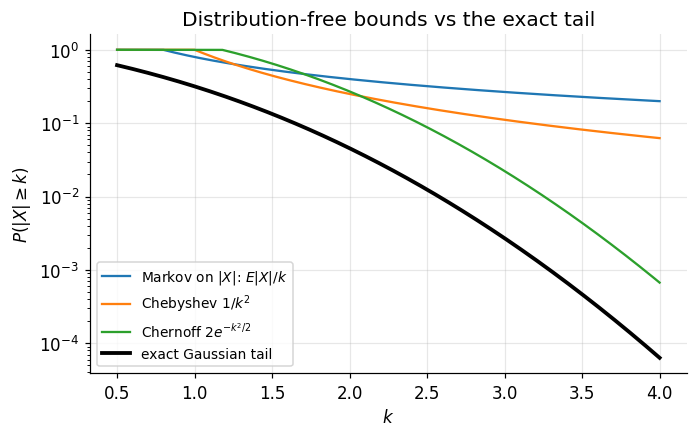

k=2:  Markov=0.3989  Chebyshev=0.2500  Chernoff(2-sided)=0.2707  exact=0.045500  Chebyshev/exact=5.5x  Chernoff/exact=5.9x
k=3:  Markov=0.2660  Chebyshev=0.1111  Chernoff(2-sided)=0.0222  exact=0.002700  Chebyshev/exact=41.2x  Chernoff/exact=8.2x
two-sided Chernoff first beats Chebyshev at k = 2.080


In [6]:
k = np.linspace(0.5, 4.0, 351)   # step 0.01, so k = 2.00 and k = 3.00 are grid points
markov = np.minimum(1.0, np.sqrt(2 / np.pi) / k)     # Markov on |X|, E|X| = sqrt(2/pi)
chebyshev = np.minimum(1.0, 1.0 / k ** 2)
chernoff_two_sided = np.minimum(1.0, 2 * np.exp(-k ** 2 / 2))
exact = 2 * stats.norm.sf(k)

fig, ax = plt.subplots()
ax.semilogy(k, markov, label=r"Markov on $|X|$: $E|X|/k$")
ax.semilogy(k, chebyshev, label="Chebyshev $1/k^2$")
ax.semilogy(k, chernoff_two_sided, label=r"Chernoff $2e^{-k^2/2}$")
ax.semilogy(k, exact, color="k", linewidth=2.5, label="exact Gaussian tail")
ax.set_xlabel("$k$")
ax.set_ylabel(r"$P(|X| \geq k)$")
ax.set_title("Distribution-free bounds vs the exact tail")
ax.legend(fontsize=9)
plt.show()

for kk in (2.0, 3.0):
    i = int(np.argmin(np.abs(k - kk)))
    print(f"k={kk:.0f}:  Markov={markov[i]:.4f}  Chebyshev={chebyshev[i]:.4f}  "
          f"Chernoff(2-sided)={chernoff_two_sided[i]:.4f}  exact={exact[i]:.6f}  "
          f"Chebyshev/exact={chebyshev[i]/exact[i]:.1f}x  "
          f"Chernoff/exact={chernoff_two_sided[i]/exact[i]:.1f}x")
cross = k[np.argmax(chernoff_two_sided < chebyshev)]
print(f"two-sided Chernoff first beats Chebyshev at k = {cross:.3f}")

At $k=2$ Chebyshev gives $0.2500$ against the exact $0.0455$ (a factor of $5.5$), while the two-sided Chernoff bound gives $0.2707$ — **worse than Chebyshev**, because the constant 2 has not yet been paid for by the exponential. The two curves cross near $k \approx 2.08$; beyond it Chernoff wins by a growing margin, and at $k=3$ it gives $0.0222$ versus Chebyshev's $0.1111$, a factor of 5 tighter and only $8.2\times$ above the exact $0.0027$. Markov on $\lvert X\rvert$ decays only like $1/k$ and is the weakest throughout. The moral is quantitative, not just qualitative: more moments buy a better *rate*, and the rate only pays off past a threshold.

### 7.3 Monte Carlo Expectation and Variance Reduction

Every Monte Carlo estimator is a statement about moments: $\hat{\mu}_N = \frac{1}{N}\sum_{i=1}^N g(X_i)$ has $E[\hat\mu_N] = E[g(X)]$ by Theorem 4.1 and $\mathrm{Var}(\hat\mu_N) = \mathrm{Var}(g(X))/N$ by Theorem 4.3, giving the universal $O(N^{-1/2})$ error rate — independent of dimension, which is why Monte Carlo beats quadrature in high dimensions.

Variance reduction is applied moment algebra:

- **Control variates**: with a correlated $C$ of known mean, $\hat\mu_{\text{cv}} = \hat\mu - c\left(\bar{C} - E[C]\right)$ has minimum variance at $c^{\star} = \frac{\mathrm{Cov}(g, C)}{\mathrm{Var}(C)}$, reducing variance by the factor $1 - \rho^2$.
- **Antithetic variates**: pairing $U$ with $1 - U$ induces negative correlation, and $\mathrm{Var}(X+Y) = \mathrm{Var}(X)+\mathrm{Var}(Y)+2\mathrm{Cov}(X,Y)$ does the rest.
- **Rao-Blackwellization**: replace $g(X, Y)$ by $E\left[g(X,Y) \mid Y\right]$; the tower property preserves the mean and Theorem 4.6 item 3 guarantees the variance cannot increase.
- **Importance sampling**: $E_p[g] = E_q\left[g\frac{p}{q}\right]$; the estimator variance is finite only if $E_q\left[g^2 p^2/q^2\right] \lt \infty$, which is why heavy-tailed proposals are safer than light-tailed ones.

**Check (measured versus predicted): control-variate variance reduction.** Estimate $E[e^U]$ for $U\sim\mathrm{Unif}(0,1)$ using $U$ itself (known mean $1/2$) as a control variate, and compare the realized variance ratio with the predicted $1-\rho^2$.

In [7]:
N = 100_000
U = rng.uniform(0, 1, size=N)
g_mc = np.exp(U)

cov_gc = float(np.cov(g_mc, U)[0, 1])
var_c = float(np.var(U, ddof=1))
c_star = cov_gc / var_c
rho_cv = cov_gc / np.sqrt(float(np.var(g_mc, ddof=1)) * var_c)
g_cv = g_mc - c_star * (U - 0.5)

var_plain = float(np.var(g_mc, ddof=1))
var_reduced = float(np.var(g_cv, ddof=1))
print(f"exact E[e^U] = e-1 = {np.e - 1:.6f}")
print(f"plain MC estimate      = {g_mc.mean():.6f}   Var = {var_plain:.6f}")
print(f"control-variate estimate = {g_cv.mean():.6f}   Var = {var_reduced:.6f}")
print(f"rho(g, C) = {rho_cv:.4f}")
print(f"predicted ratio 1-rho^2 = {1 - rho_cv**2:.5f}   observed = {var_reduced/var_plain:.5f}")
assert abs(var_reduced / var_plain - (1 - rho_cv ** 2)) < 1e-3

exact E[e^U] = e-1 = 1.718282
plain MC estimate      = 1.721036   Var = 0.242642
control-variate estimate = 1.718350   Var = 0.003937
rho(g, C) = 0.9919
predicted ratio 1-rho^2 = 0.01623   observed = 0.01623


The observed variance ratio matches $1-\rho^2$ to better than $10^{-3}$: with $\rho = 0.992$ the control variate removes 98.4% of the variance, the same accuracy a $62\times$ larger sample would have bought, at no extra cost. Both estimators remain unbiased — their means agree with $e-1$ — which is the point of a control variate: it moves variance, never the mean.

### 7.4 When a Hypothesis Fails

Theorem 4.5 item 2 needs $\sigma^2 \lt \infty$. Drop it and nothing survives: the bound becomes vacuous, and the sample mean itself stops concentrating.

**Check (counterexample): infinite variance destroys concentration.** Running means of i.i.d. standard Cauchy data against i.i.d. standard normal data, and the sample variance of the Cauchy data as $n$ grows.

In [8]:
N_hv = 200_000
cauchy = rng.standard_cauchy(N_hv)
gauss = rng.standard_normal(N_hv)
idx = np.arange(1, N_hv + 1)
run_c = np.cumsum(cauchy) / idx
run_g = np.cumsum(gauss) / idx

tail = slice(1000, None)
print(f"n >= 1000 running mean, max |mean|:  Cauchy={np.abs(run_c[tail]).max():.4f}   "
      f"Normal={np.abs(run_g[tail]).max():.4f}")
print(f"fraction of n >= 1000 with |mean| > 0.1: Cauchy={(np.abs(run_c[tail])>0.1).mean():.3f}   "
      f"Normal={(np.abs(run_g[tail])>0.1).mean():.3f}")
for n in (10 ** 3, 10 ** 4, 10 ** 5):
    print(f"  n={n:>7}: Cauchy sample variance = {cauchy[:n].var():12.1f}   "
          f"Normal sample variance = {gauss[:n].var():.4f}")
assert np.abs(run_c[tail]).max() > 10 * np.abs(run_g[tail]).max()

n >= 1000 running mean, max |mean|:  Cauchy=5.8499   Normal=0.0785
fraction of n >= 1000 with |mean| > 0.1: Cauchy=0.662   Normal=0.000
  n=   1000: Cauchy sample variance =      10034.8   Normal sample variance = 1.0167
  n=  10000: Cauchy sample variance =      92927.0   Normal sample variance = 0.9833
  n= 100000: Cauchy sample variance =      45576.4   Normal sample variance = 1.0014


After $n = 1000$ the Gaussian running mean never leaves $\pm 0.08$; the Cauchy running mean wanders past 5 and sits outside $\pm 0.1$ for two-thirds of the remaining range. The sample variance of the Cauchy data never settles: it swings between $10^4$ and $10^5$ as $n$ grows, because it is estimating an infinite quantity, while the Gaussian sample variance is pinned at $1.00$ throughout. This is the precise sense in which Chebyshev "fails": there is no $\sigma^2$ to put in the numerator, so the inequality says nothing, and indeed $\bar X_n$ has exactly the standard Cauchy law for every $n$.

### 7.5 Cumulants Decay at a Measurable Rate

Proof 5.7 predicts that for a sum of $n$ i.i.d. copies the standardized skewness falls like $n^{-1/2}$ and the excess kurtosis like $n^{-1}$. Both exponents are measurable: fit a straight line to $\log(\text{shape})$ against $\log n$ and read off the slope.

**Figure 3 — measured versus predicted decay of the third and fourth cumulants.** Sums of $n$ i.i.d. $\text{Exponential}(1)$ variables, for which $\gamma_1(S_n) = 2/\sqrt{n}$ and $\gamma_2(S_n) = 6/n$ exactly. Observed slopes on a log-log axis are compared with the predicted $-\tfrac12$ and $-1$.

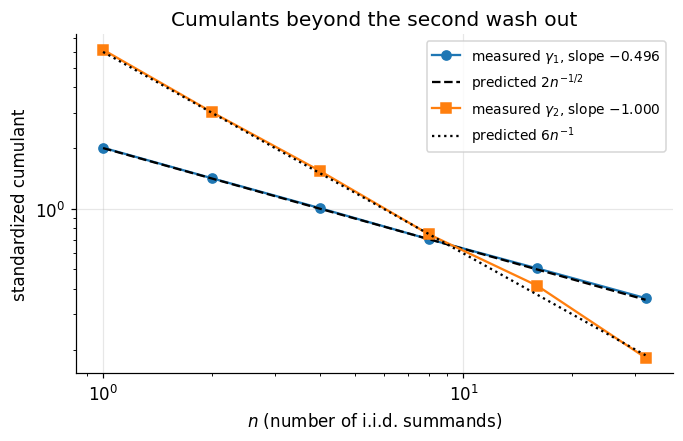

skewness       : observed slope -0.4962   predicted -0.5
excess kurtosis: observed slope -1.0003   predicted -1.0
n=32: gamma_1 observed 0.3601 vs 2/sqrt(32)=0.3536;  gamma_2 observed 0.1824 vs 6/32=0.1875


In [9]:
M_rep = 200_000
ns = np.array([1, 2, 4, 8, 16, 32])
skew_obs, exkurt_obs = [], []
for n in ns:
    S = rng.standard_exponential(size=(M_rep, n)).sum(axis=1)
    zc = (S - S.mean()) / S.std(ddof=0)
    skew_obs.append(float(np.mean(zc ** 3)))
    exkurt_obs.append(float(np.mean(zc ** 4) - 3.0))
skew_obs, exkurt_obs = np.array(skew_obs), np.array(exkurt_obs)

slope_s = float(np.polyfit(np.log(ns), np.log(skew_obs), 1)[0])
slope_k = float(np.polyfit(np.log(ns), np.log(exkurt_obs), 1)[0])

fig, ax = plt.subplots()
ax.loglog(ns, skew_obs, "o-", label=fr"measured $\gamma_1$, slope ${slope_s:.3f}$")
ax.loglog(ns, 2 / np.sqrt(ns), "k--", label=r"predicted $2n^{-1/2}$")
ax.loglog(ns, exkurt_obs, "s-", label=fr"measured $\gamma_2$, slope ${slope_k:.3f}$")
ax.loglog(ns, 6 / ns, "k:", label=r"predicted $6n^{-1}$")
ax.set_xlabel("$n$ (number of i.i.d. summands)")
ax.set_ylabel("standardized cumulant")
ax.set_title("Cumulants beyond the second wash out")
ax.legend(fontsize=9)
plt.show()

print(f"skewness       : observed slope {slope_s:+.4f}   predicted -0.5")
print(f"excess kurtosis: observed slope {slope_k:+.4f}   predicted -1.0")
print(f"n=32: gamma_1 observed {skew_obs[-1]:.4f} vs 2/sqrt(32)={2/np.sqrt(32):.4f};  "
      f"gamma_2 observed {exkurt_obs[-1]:.4f} vs 6/32={6/32:.4f}")
assert abs(slope_s + 0.5) < 0.05 and abs(slope_k + 1.0) < 0.08

The measured slopes are $-0.496$ and $-1.000$ against the predicted $-0.5$ and $-1$, so the third cumulant dies as $n^{-1/2}$ and the fourth twice as fast, exactly as cumulant additivity requires. This is the central limit theorem seen one cumulant at a time: the standardized law keeps its first two cumulants and sheds all the rest, and the plot shows the shedding rate. It also explains the practical asymmetry — skewness is the dominant departure from normality at moderate $n$, which is why Edgeworth corrections start with the $\gamma_1$ term.

### 7.6 Moments in the Training Loop

- **Adam and RMSProp are moment estimators.** They maintain exponential moving averages $m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t$ and $v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2$ — a first and an uncentered second moment of the gradient — and divide by $\sqrt{v_t}$ to normalize the step scale. The bias-correction factors $1/(1-\beta_1^t)$ exist precisely because initializing at zero biases the EMA toward zero early in training.
- **Batch normalization** subtracts a batch mean and divides by a batch standard deviation, with running moments kept for inference; the train/eval discrepancy is entirely a story about which moment estimate is in use.
- **Gradient noise scale.** $\mathrm{Var}(\hat{g}_B) = \sigma^2/B$ for batch size $B$ by Theorem 4.3, so the signal-to-noise ratio of a minibatch gradient grows as $\sqrt{B}$ — the moment calculation behind linear learning-rate scaling rules.

## 8. Applications

### 8.1 AI / Machine Learning

- **Risk minimization is expectation minimization.** Supervised learning minimizes $E_{(x,y)\sim\mathcal{D}}\left[\ell(f_\theta(x), y)\right]$, approximated by the empirical mean; the entire generalization question is how far a sample mean sits from its expectation, answered by the concentration inequalities of Theorem 4.5.
- **The optimal regressor is a conditional expectation.** Minimizing squared error over all measurable functions gives $f^{\star}(x) = E[Y \mid X = x]$ by Theorem 4.6 item 4 — so a well-trained regressor is an estimate of a conditional mean, and its irreducible error is $E\left[\mathrm{Var}(Y \mid X)\right]$.
- **Aleatoric vs epistemic uncertainty** is Eve's law with $Y$ the model parameters: $\mathrm{Var}(\text{prediction}) = E_\theta\left[\mathrm{Var}(y \mid \theta)\right] + \mathrm{Var}_\theta\left(E[y \mid \theta]\right)$. Deep ensembles estimate the second term; more data shrinks it, while the first term does not shrink.
- **The ELBO is Jensen's inequality** (Proof 5.5), and the gap is exactly $D_{\mathrm{KL}}\left(q(z) \Vert p(z \mid x)\right)$ — so tightening the bound and improving the posterior approximation are the same act.
- **The REINFORCE estimator** $\nabla_\theta E\left[R\right] = E\left[R\,\nabla_\theta\ln\pi_\theta\right]$ has notoriously high variance; baselines $b$ are control variates that leave the mean unchanged (since $E\left[\nabla_\theta\ln\pi_\theta\right] = 0$) while reducing variance — the Section 7.3 algebra deployed in policy-gradient RL, worked out in Problem L2.3.
- **Bias-variance in practice**: bagging averages high-variance low-bias predictors, boosting sequentially reduces bias, and both are read off Corollary 4.7.

### 8.2 Physics & Engineering

- **Statistical mechanics is a cumulant theory.** The partition function $Z(\beta)$ *is* an MGF: $\left\langle E\right\rangle = -\partial_\beta \ln Z$ and $\mathrm{Var}(E) = \partial_\beta^2\ln Z = k_BT^2 C_V$ — a fluctuation-dissipation relation that equates a second cumulant with a measurable heat capacity (Problem L2.4). Cumulant additivity (Theorem 4.4 item 4) over $N$ independent subsystems then gives relative fluctuations $\propto N^{-1/2}$, which is why macroscopic thermodynamics looks deterministic.
- **Error propagation.** For $f(X_1,\ldots,X_n)$ with small fluctuations, $\mathrm{Var}(f) \approx \sum_{i,j}\frac{\partial f}{\partial x_i}\frac{\partial f}{\partial x_j}\mathrm{Cov}(X_i, X_j)$ — the delta method, and the standard uncertainty-budget formula in metrology. Correlated instrument errors enter through the off-diagonal terms of $\Sigma$ in Theorem 4.3 and are what make naive quadrature-sum error bars wrong.
- **Signal processing.** The autocorrelation function is a covariance in disguise, and the Wiener-Khinchin theorem identifies its Fourier transform with the power spectral density; matched filtering is exactly the equality case of Cauchy-Schwarz established in Proof 5.3.
- **Diffusion and transport.** Einstein's relation $\left\langle x^2 \right\rangle = 2Dt$ is a second-moment computation for Brownian motion, and all higher cumulants vanish because the increments are Gaussian.

### 8.3 Key Formula Summary

| Object | Formula | Notes |
|---|---|---|
| Expectation | $E[X] = \int_\Omega X\,dP$ | Linear without any independence |
| LOTUS | $E[g(X)] = \int g\,dP_X$ | No need for the law of $g(X)$ |
| Tail formula | $E[X] = \int_0^\infty P(X \gt t)\,dt$ for $X \ge 0$ | Sum version for integer $X$ |
| Variance | $\mathrm{Var}(X) = E[X^2] - E[X]^2$ | True in $\mathbb{R}$; never compute it this way |
| Sum variance | $\mathrm{Var}\left(\sum_i X_i\right) = \mathbf{1}^\top\Sigma\mathbf{1}$ | Cross terms unless uncorrelated |
| Correlation | $\rho = \mathrm{Cov}(X,Y)/(\sigma_X\sigma_Y)$ | Needs $\sigma_X,\sigma_Y \gt 0$; linear dependence only |
| MGF / CGF | $M(t) = E[e^{tX}]$, $K = \ln M$ | $\kappa_n$ additive over independent sums |
| Kurtosis | $\beta_2 = \mu_4/\sigma^4$, excess $= \beta_2 - 3$ | Gaussian benchmark is 3 |
| Markov | $P(X \ge a) \le E[X]/a$ | $X \ge 0$; one moment |
| Chebyshev | $P\left(\lvert X-\mu \rvert \ge k\sigma\right) \le 1/k^2$ | Needs $\sigma^2 \lt \infty$ |
| Chernoff | $P(X \ge a) \le \inf_{t \gt 0}e^{-ta}M(t)$ | Needs $M$ finite for some $t \gt 0$ |
| Jensen | $E[g(X)] \ge g(E[X])$, $g$ convex | Source of the ELBO and $D_{\mathrm{KL}} \ge 0$ |
| Tower | $E\left[E[X \mid Y]\right] = E[X]$ | Adam's law |
| Total variance | $\mathrm{Var}(X) = E\left[\mathrm{Var}(X \mid Y)\right] + \mathrm{Var}\left(E[X \mid Y]\right)$ | Aleatoric plus epistemic |
| Bias-variance | $\mathrm{MSE} = \text{bias}^2 + \text{variance}$ | Unbiasedness is not optimality |

## 9. Key Takeaways

1. For integrable $X_i$ on a common space, $E\left[\sum_i X_i\right] = \sum_i E[X_i]$ — dependence never enters, which is why indicator decomposition works (Theorem 4.1, Example 6.1).
2. For Borel $g$ with $E\lvert g(X)\rvert \lt \infty$, $E[g(X)] = \int g\,dP_X$: the law of $g(X)$ is never needed (Theorem 4.2, Proof 5.2).
3. For square-integrable $X_i$, $\mathrm{Var}\left(\sum_i X_i\right) = \mathbf{1}^\top\Sigma\mathbf{1}$, additive only under *uncorrelatedness* — a strictly weaker hypothesis than independence, and one that $\mathcal{N}(0,1)$ with its square satisfies while being functionally dependent (Theorem 4.3).
4. If $M_X$ is finite on an open interval around 0 then moments determine the law and cumulants add over independent summands; without that interval both statements can fail, and the Lognormal is the standard witness (Theorem 4.4, Problem L3.4).
5. Markov needs only $X \ge 0$, Chebyshev needs $\sigma^2 \lt \infty$, Chernoff needs $M_X(t) \lt \infty$ for some $t \gt 0$; each extra assumption buys a better decay rate, and each bound is attained by some law, so none can be improved without adding hypotheses (Theorem 4.5, Example 6.5).
6. For convex $g$ and integrable $X$, $E[g(X)] \ge g(E[X])$ with equality iff $g$ is affine on the support — the gap is a bias that more data does not remove (Theorem 4.5 item 4, Proof 5.5).
7. For $X \in L^2$, $\mathrm{Var}(X) = E[\mathrm{Var}(X\mid Y)] + \mathrm{Var}(E[X\mid Y])$, and $E[X\mid Y]$ is the minimum-MSE predictor with irreducible error $E[\mathrm{Var}(X\mid Y)]$ (Theorem 4.6, Proof 5.6).
8. For non-random $\theta$ and $\hat\theta \in L^2$, $\mathrm{MSE}(\hat\theta) = \text{bias}^2 + \mathrm{Var}$, so a biased estimator can strictly dominate an unbiased one (Corollary 4.7, Example 6.6).

## 10. References

| Source | Chapters / Sections | Coverage |
|---|---|---|
| Blitzstein & Hwang, *Introduction to Probability* (2nd ed.) | Ch. 4 (§4.2 linearity), Ch. 6 (§6.4 MGFs), Ch. 9 (§9.1-9.5 conditional expectation), Ch. 10 (§10.1-10.4 inequalities) | Expectation stories, moments and MGFs, conditional expectation, inequalities. |
| Wasserman, *All of Statistics* | §3.1-3.5, §4.1-4.2 (Thm 4.1 Markov, Thm 4.2 Chebyshev, Thm 4.8 Hoeffding) | Expectation, variance, and the standard inequality toolkit. |
| Casella & Berger, *Statistical Inference* (2nd ed.) | §2.2-2.3 (Thm 2.3.11 MGF uniqueness), §4.4 (Thm 4.4.7 Adam's law, Thm 4.4.15 Eve's law) | Moments, MGFs, conditional expectation and variance. |
| Ross, *A First Course in Probability* (10th ed.) | Ch. 7, §7.2 (linearity), §7.4 (covariance), §7.5 (conditional expectation) | Properties of expectation, covariance, conditional expectation. |
| Durrett, *Probability: Theory and Examples* (5th ed.) | §1.6 (Thm 1.6.9 change of variables), §4.1 (Thm 4.1.4 existence of conditional expectation) | Integration theory; conditional expectation as an $L^2$ projection. |
| Billingsley, *Probability and Measure* (3rd ed.) | §21 (Thm 21.1 change of variables), §34 (Thm 34.1 Radon-Nikodym construction) | Rigorous expectation and conditional expectation. |
| Lukacs, *Characteristic Functions* (2nd ed.) | Thm 7.3.5 (Marcinkiewicz) | A CGF cannot be a polynomial of degree $\gt 2$. |
| Bishop, *Pattern Recognition and Machine Learning* | §1.5.5 (squared-error decision theory), §3.2 (bias-variance) | Decision theory; the bias-variance decomposition. |
| Murphy, *Probabilistic Machine Learning: An Introduction* | §2.2 (moments), §4.7.6 (bias-variance and estimator risk) | Moments and estimator risk in an ML framing. |
| Boucheron, Lugosi & Massart, *Concentration Inequalities* | Ch. 2 (§2.1 Markov/Chernoff, §2.3 Hoeffding's lemma, Lemma 2.2) | Markov to Chernoff to sub-Gaussian concentration. |
| Owen, *Monte Carlo Theory, Methods and Examples* | Ch. 8 (§8.9 control variates), Ch. 9 (§9.1 importance sampling) | Control variates, antithetics, Rao-Blackwellization. |

**Reading path**: Blitzstein & Hwang §4.2 for linearity and indicator tricks, then Ch. 9 for conditional expectation; Wasserman Ch. 4 for the inequalities; Boucheron, Lugosi & Massart §2.1-2.3 for the concentration machinery that modern learning theory runs on; and Bishop §3.2 for the bias-variance payoff.